# Phase 2 — Braking: can the air system tell the story?

Building on the Phase 1 **braking** state, this notebook asks three honest questions:
1. Can the **air-system sensors alone** tell when the train is braking — without using
   speed at all?
2. Are there distinct **braking-intensity classes** (gentle / hard / emergency), or is
   intensity a smooth continuum?
3. Does braking behaviour **change before a brake failure**?

The golden rule throughout (see **leakage** in the glossary): the sensors that *defined*
the braking state (motion) are never used to *predict* it. The air-system sensors, which
never touched the definition, are the predictors.

> **How to read this notebook.** Each step has three short notes:
> **What we did** (the action), **What it means** (the plain-English result), and
> **How confident** (how much to trust it). Technical terms are explained at the very
> bottom, in *"Techniques explained"* — every method used here is in that glossary with
> an everyday analogy. Nothing assumes a data-science background.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = ROOT / "results" / "tables"
P1 = ROOT / "results" / "plots" / "phase1"
P2 = ROOT / "results" / "plots" / "phase2"
LOGS = ROOT / "logs"
pd.set_option("display.max_columns", 40)
print("Project root:", ROOT)

Project root: C:\Users\MSC\Programming\Interdisciplinary Project


## 0. Keeping predictors and targets separate (no cheating)

**What we did:** we sorted every sensor into a role — *velocity* (motion; targets only),
*actuation* (the brake command), *auxiliary* (independent health sensors like reservoir
and load pressure) — and proved the predictor sensors never overlap with what defined the
target.

In [2]:
print((LOGS / "phase2" / "leakage_audit.txt").read_text(encoding="utf-8")[:900])

Phase 2 -- Leakage audit

Rule: the modality that DEFINES a target must never predict it.
Velocity/kinematics -> targets. Actuation + auxiliary -> predictors.

Window features classified: 208
  role counts: {'actuation': 120, 'auxiliary': 60, 'other': 16, 'velocity': 12}
  predictor pool (actuation+auxiliary): 180
  velocity target pool: 12
  predictor/target overlap: 0 -> DISJOINT OK

Phase-1 states are defined by KINEMATICS ONLY (Option A). The 12
state-defining features (velocity + acceleration family):
    - TRAIN_SPEED_ACTUAL__mean
    - TRAIN_SPEED_ACTUAL__std
    - TRAIN_SPEED_ACTUAL__min
    - TRAIN_SPEED_ACTUAL__max
    - acceleration__mean
    - acceleration__std
    - acceleration__min
    - acceleration__max
    - jerk__mean
    - jerk__std
    - velocity_change_rate__mean
    - velocity_change_rate__std

  predicto


**What it means:** any predictive success below is *real*, not an artefact
of predicting a definition with itself.

**How confident:** this is a structural guarantee, checked automatically.

## 1. Braking events (and a reality check)

**What we did:** a braking event = one continuous stretch of the braking state. We also
flag whether the train was genuinely decelerating.

,metric,value
0,n_events,126702.000000
1,n_real_deceleration,126635.000000
2,frac_real_deceleration,0.999500
3,duration_mean_s,23.444018
4,duration_median_s,20.000000
5,duration_p95_s,30.000000
6,events_7d_pre_failure,23033.000000
7,events_30d_pre_failure,82664.000000
8,v1_event_count,157823.000000
9,ratio_vs_v1,0.803000


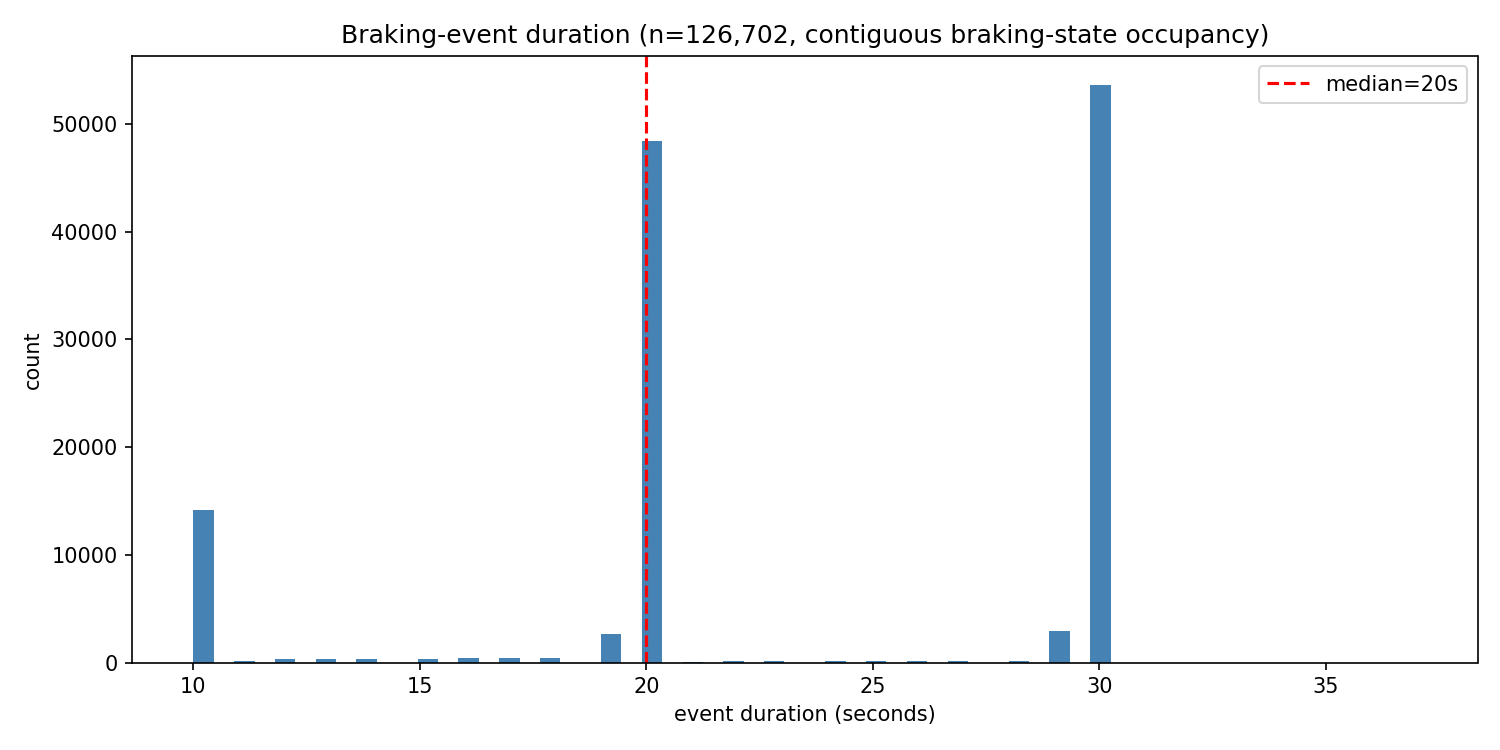

In [3]:
display(pd.read_csv(TABLES / "event_summary.csv"))
display(Image(filename=str(P2 / "event_duration_distribution.png")))

**What it means:** ~127,000 braking events, and **99.9% are genuine
decelerations** (the old "parked with brake held" contamination is gone, thanks to the
Phase 1 fix).

**How confident:** high.

## 2. Can the air sensors alone detect braking?

**What we did:** predict "braking vs not" for each window using only air-system sensors
(no speed). Two tiers — *auxiliary only*, then *+ the brake command* — and three
transparent models (decision tree, LDA, QDA), scored on unseen data.

,tier,model,n_features,accuracy,balanced_accuracy,precision_braking,recall_braking,f1_braking,roc_auc
0,auxonly,dt,60,0.731,0.796,0.424,0.906,0.577,0.878
1,auxonly,lda,60,0.820,0.621,0.621,0.287,0.392,0.813
2,auxonly,qda,60,0.521,0.693,0.295,0.983,0.454,0.844
3,full,dt,180,0.754,0.825,0.449,0.945,0.609,0.910
4,full,lda,180,0.877,0.726,0.858,0.473,0.610,0.924
5,full,qda,180,0.844,0.746,0.622,0.583,0.602,0.901


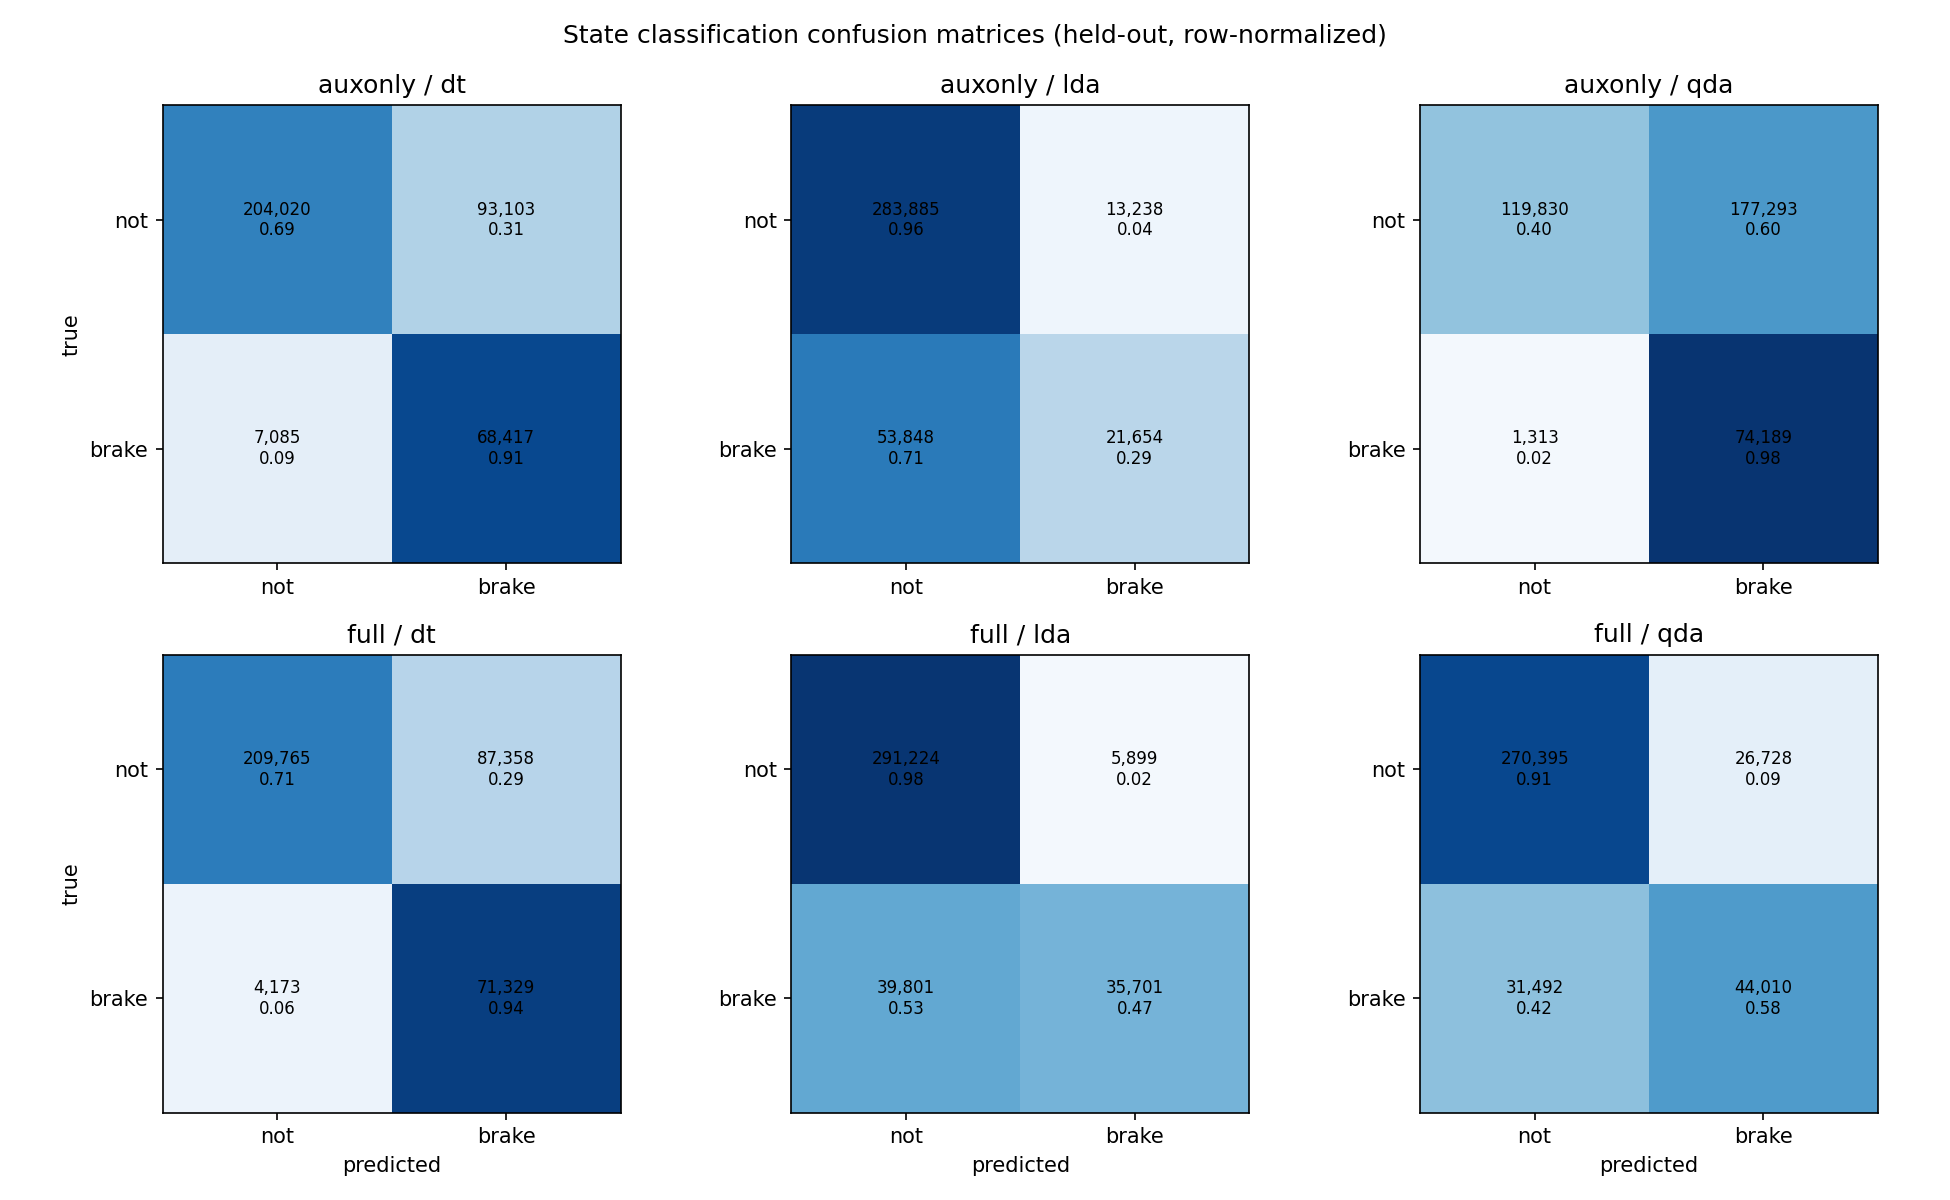

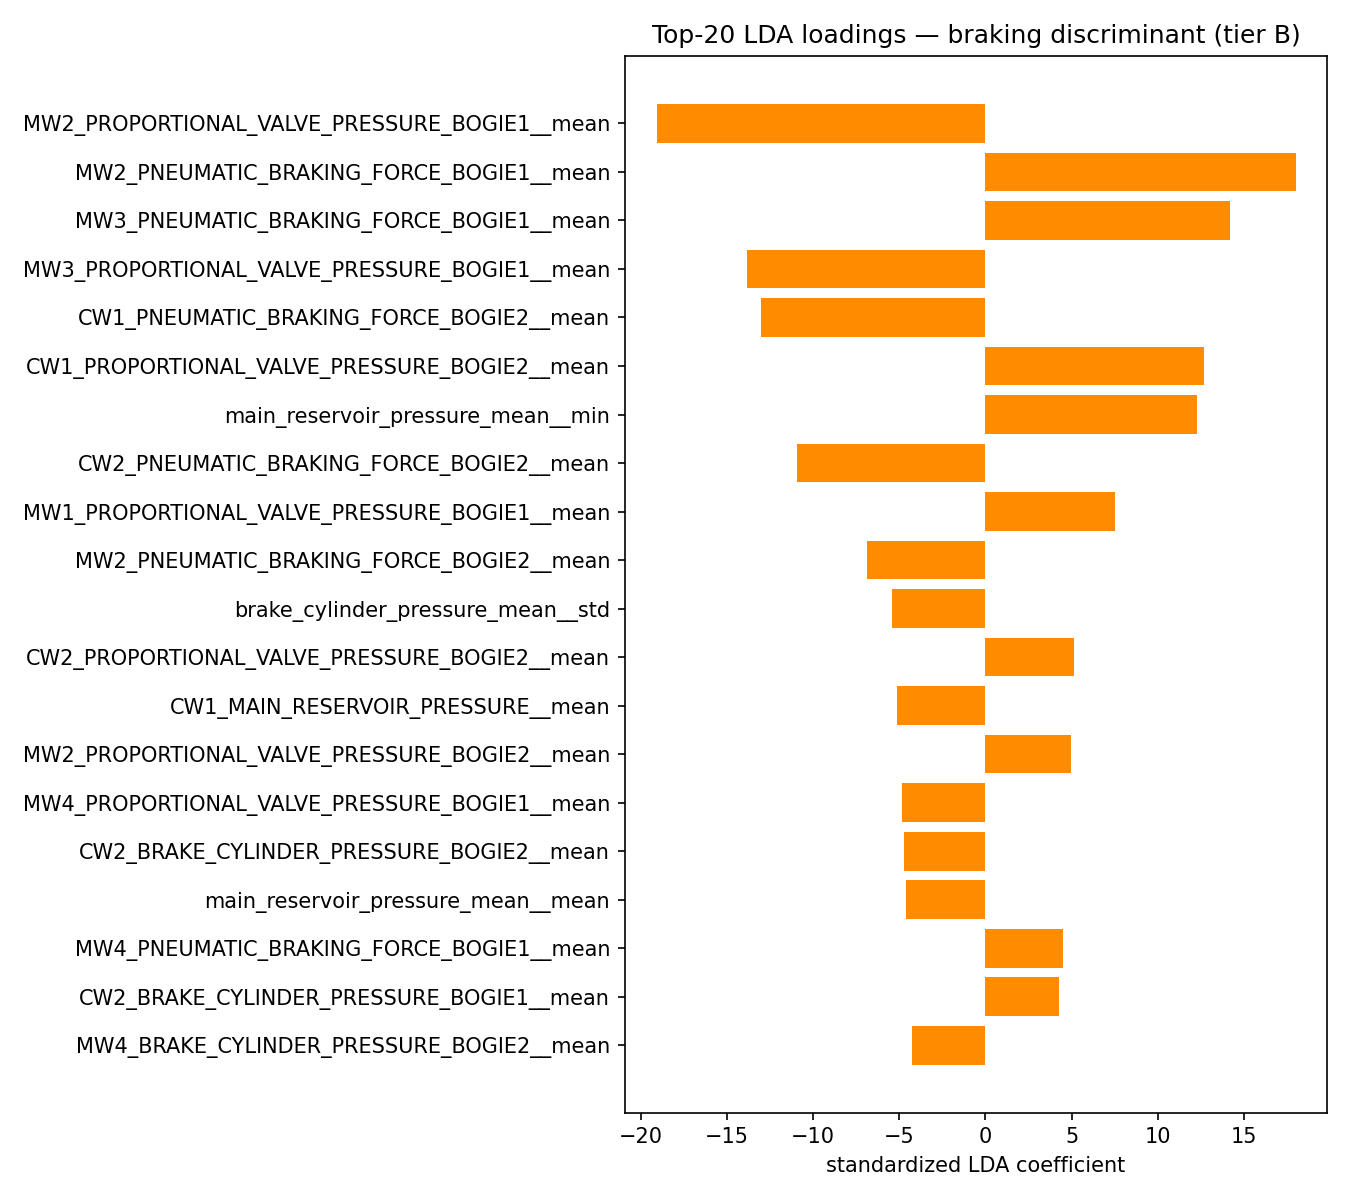

In [4]:
display(pd.read_csv(TABLES / "state_classification_metrics.csv").round(3))
display(Image(filename=str(P2 / "state_clf_confusion.png")))
display(Image(filename=str(P2 / "state_clf_lda_coeffs.png")))

**What it means:** the air sensors recover braking well — **ROC-AUC ≈ 0.9**
— and the *auxiliary* (non-command) sensors alone already reach ~0.88. So braking leaves a
real fingerprint across the air system, not just in the brake command.

**How confident:** solid and honest. These numbers are lower than a naive "predict the
definition with itself" setup would show — that drop *is* the value of doing it cleanly.

## 3. Are there braking-intensity classes? → No, it's a continuum

**What we did:** we tested whether deceleration falls into distinct classes
(gentle/hard/emergency) using BIC + silhouette + stability — letting the data decide.

,k,gmm_bic,gmm_aic,kmeans_silhouette,davies_bouldin,bootstrap_ari,min_cluster_frac
0,1,940635.709,940547.967,NaN,NaN,NaN,NaN
1,2,884034.272,883849.040,0.406,0.925,0.992,0.408
2,3,811851.997,811569.274,0.407,0.714,0.832,0.000
3,4,782709.437,782329.223,0.390,0.797,0.868,0.000
4,5,778574.524,778096.820,0.315,0.899,0.964,0.000
5,6,767810.272,767235.077,0.278,0.973,0.678,0.000


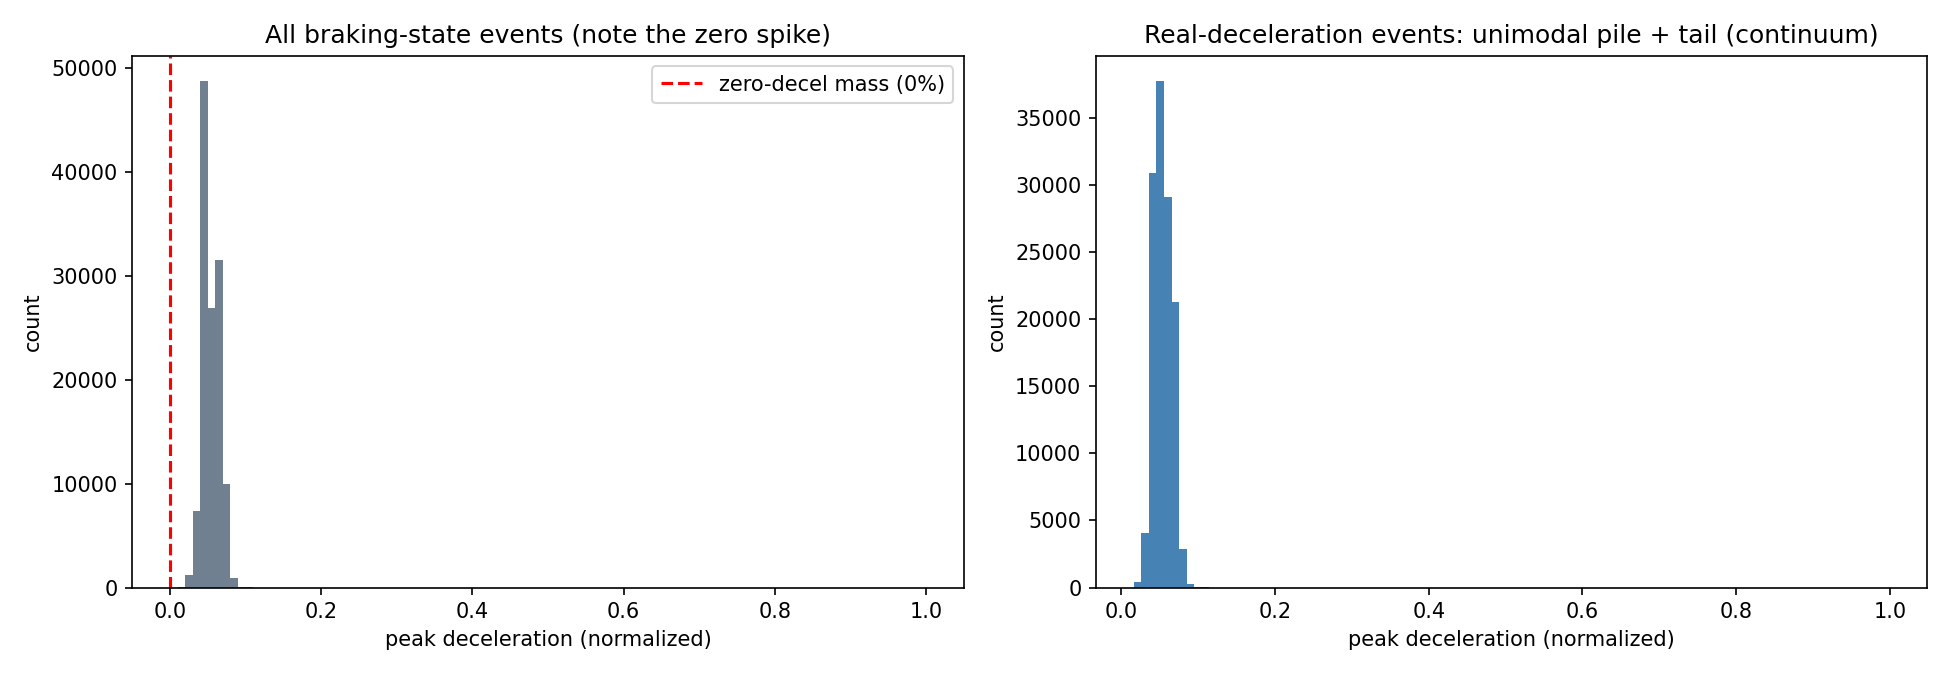

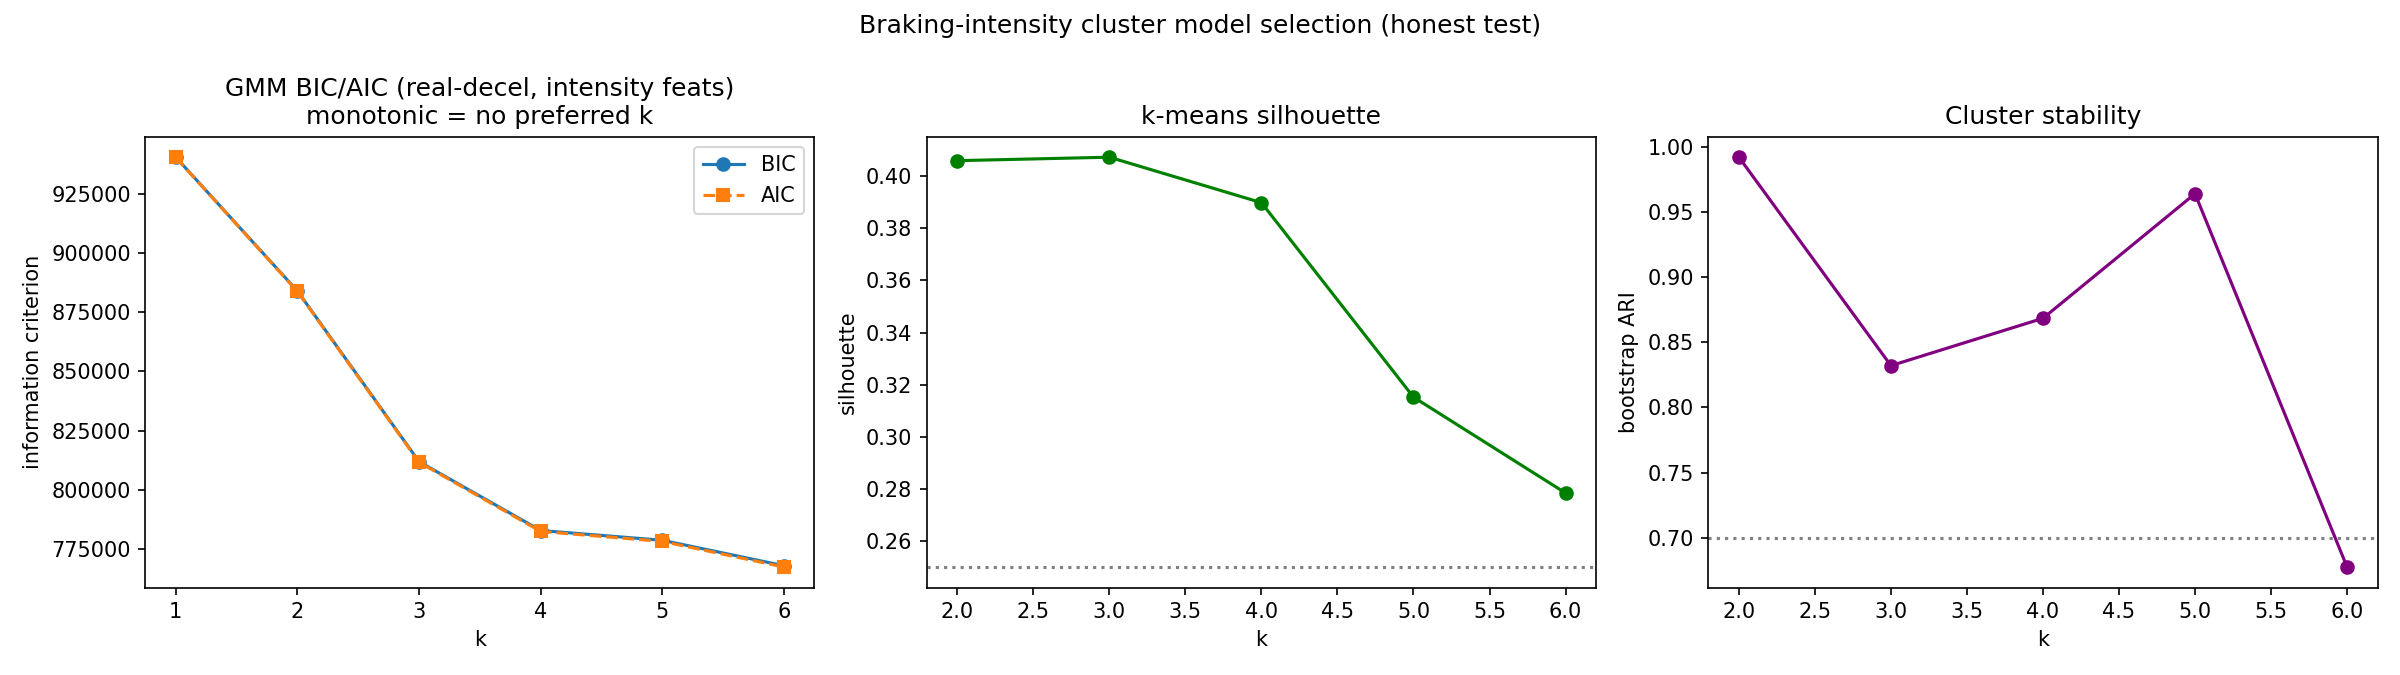

In [5]:
display(pd.read_csv(TABLES / "cluster_selection.csv").round(3))
display(Image(filename=str(P2 / "intensity_distribution.png")))
display(Image(filename=str(P2 / "cluster_model_selection.png")))

**What it means:** there is **no natural number of classes** — the score
keeps "improving" with more groups and the groups aren't stable. Deceleration is a smooth
**continuum** (one common level with a long tail of harder stops). So we do **not** invent
"light/hard/emergency" classes.

**How confident:** high — this is a clear, honest negative result.

## 4. How much of braking *intensity* do the air sensors explain?

**What we did:** since intensity is continuous, we *predict the deceleration value* from
the non-speed sensors (held-out R²; baseline = guessing the average).

,scope,target,tier,with_duration,model,n_features,r2,mae,baseline_r2,baseline_mae
0,real_decel,peak_deceleration,auxonly,False,lin,10,0.162,0.009,-0.0,0.010
1,real_decel,peak_deceleration,auxonly,False,tree,10,0.244,0.008,-0.0,0.010
2,real_decel,peak_deceleration,auxonly,True,lin,11,0.232,0.009,-0.0,0.010
3,real_decel,peak_deceleration,auxonly,True,tree,11,0.307,0.008,-0.0,0.010
4,real_decel,peak_deceleration,full,False,lin,22,0.243,0.008,-0.0,0.010
5,real_decel,peak_deceleration,full,False,tree,22,0.429,0.007,-0.0,0.010
6,real_decel,peak_deceleration,full,True,lin,23,0.243,0.008,-0.0,0.010
7,real_decel,peak_deceleration,full,True,tree,23,0.401,0.007,-0.0,0.010
8,real_decel,mean_deceleration,auxonly,False,lin,10,0.093,0.004,-0.0,0.004
9,real_decel,mean_deceleration,auxonly,False,tree,10,0.234,0.004,-0.0,0.004


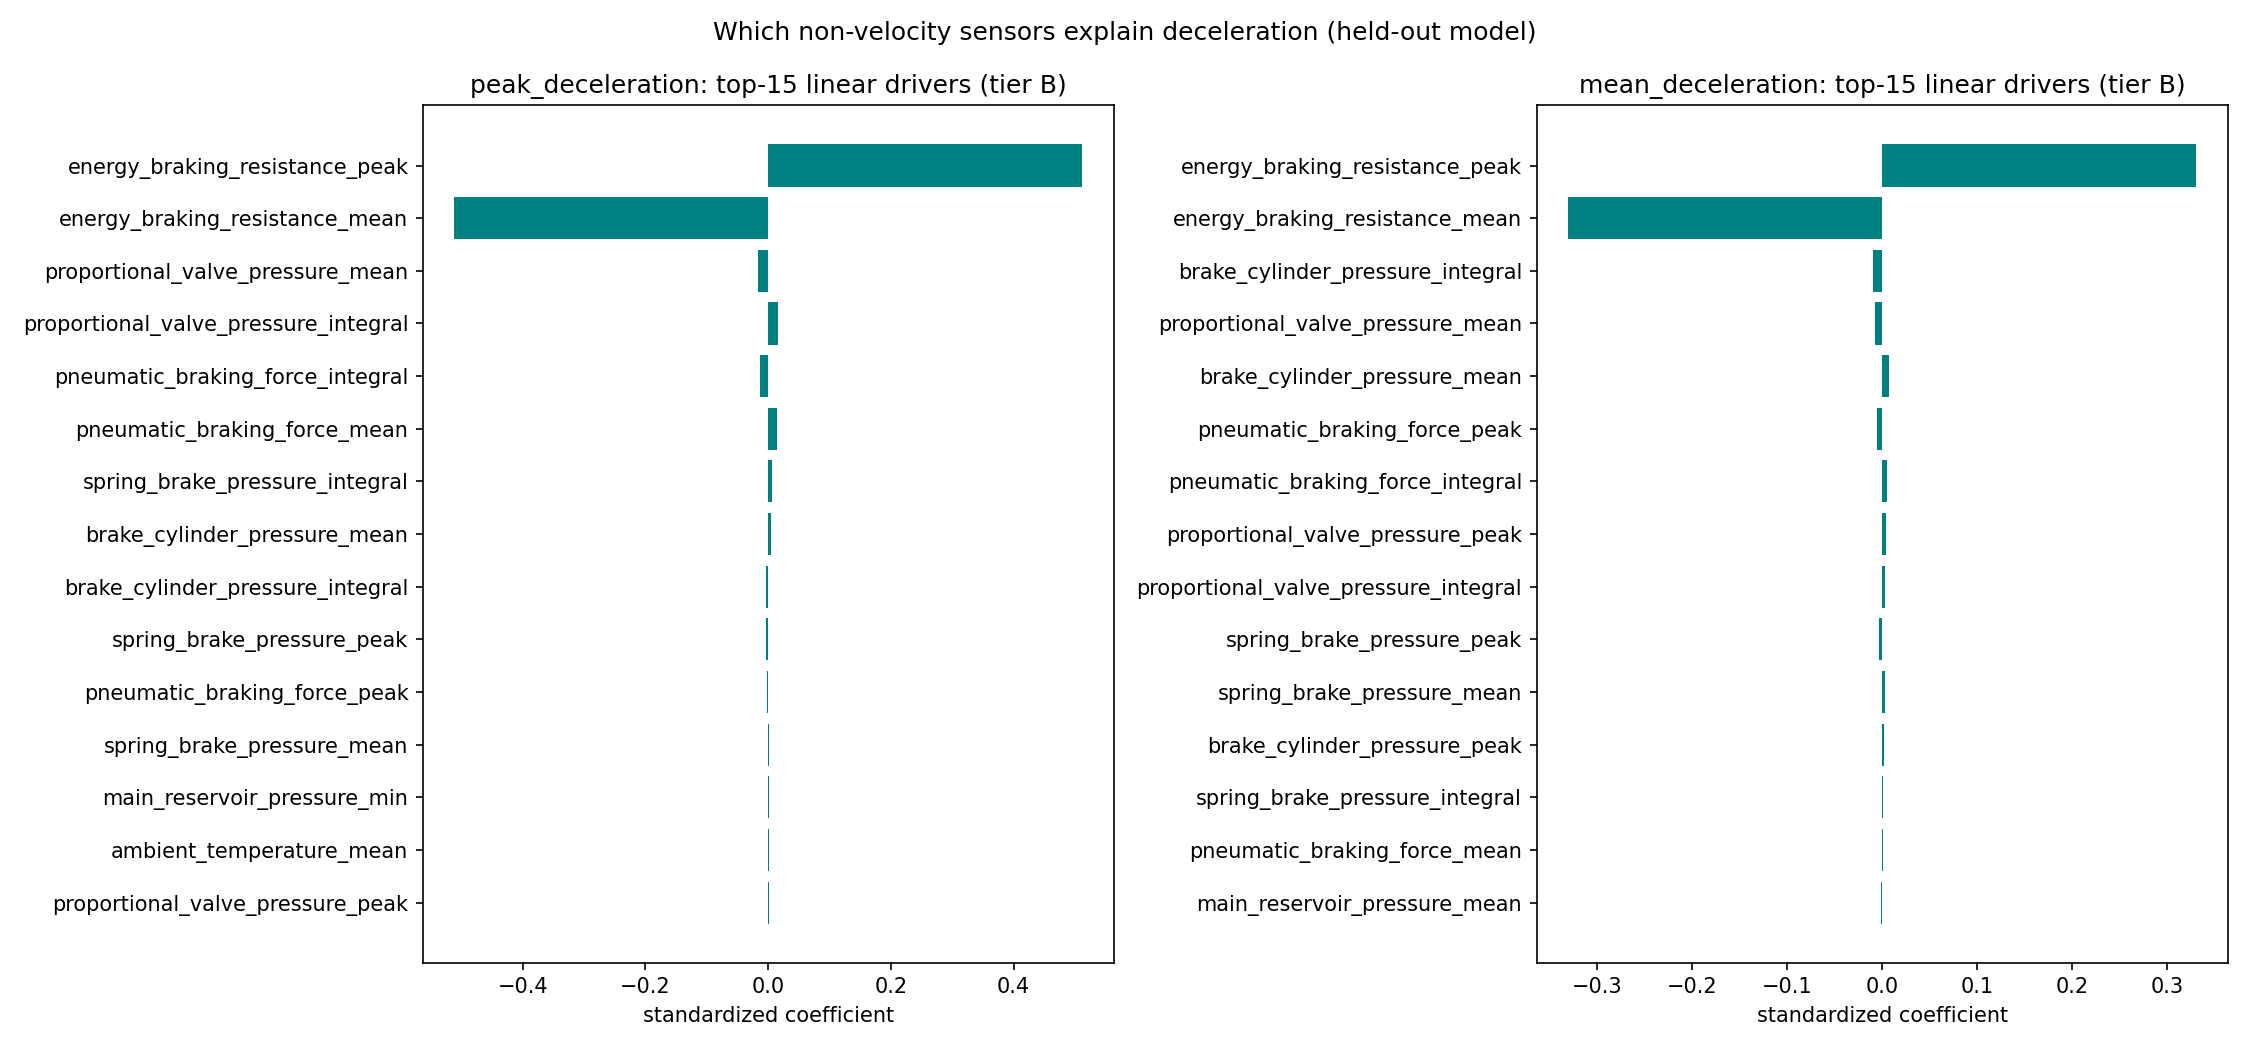

In [6]:
r = pd.read_csv(TABLES / "decel_regression_metrics.csv")
display(r[r.scope == "real_decel"].round(3).reset_index(drop=True))
display(Image(filename=str(P2 / "decel_regression_coeffs.png")))

**What it means:** the air sensors explain roughly **43% of peak** and
**47% of mean** deceleration on unseen data — substantial, given speed is never used.
Auxiliary sensors alone explain a meaningful share; the brake command adds the rest.

**How confident:** this is the headline result and the cleanest one — fully cross-modal,
no class assumptions.

## 5. Does braking change before a brake failure? (8 failures — small)

**What we did:** compared braking in the 7 days before each of the 8 brake failures
against normal periods, reading the **effect size** (Cliff's delta), not just p-values.

,feature,cliffs_delta,cliffs_ci_lo,cliffs_ci_hi,sig_bonferroni
9,energy_braking_resistance_mean,-0.201,-0.241,-0.163,True
8,load_pressure_mean,-0.103,-0.138,-0.067,True
4,jerk_rms,0.054,0.018,0.094,True
0,brake_cylinder_pressure_integral,-0.040,-0.077,-0.007,True
2,pneumatic_braking_force_mean,-0.032,-0.067,0.007,True
1,brake_cylinder_pressure_peak,-0.030,-0.070,0.004,True
3,spring_brake_pressure_mean,0.029,-0.002,0.064,True
7,main_reservoir_pressure_rate_mean,0.016,-0.018,0.049,True
6,main_reservoir_pressure_drop,-0.012,-0.050,0.023,False
5,peak_deceleration,-0.005,-0.040,0.026,False


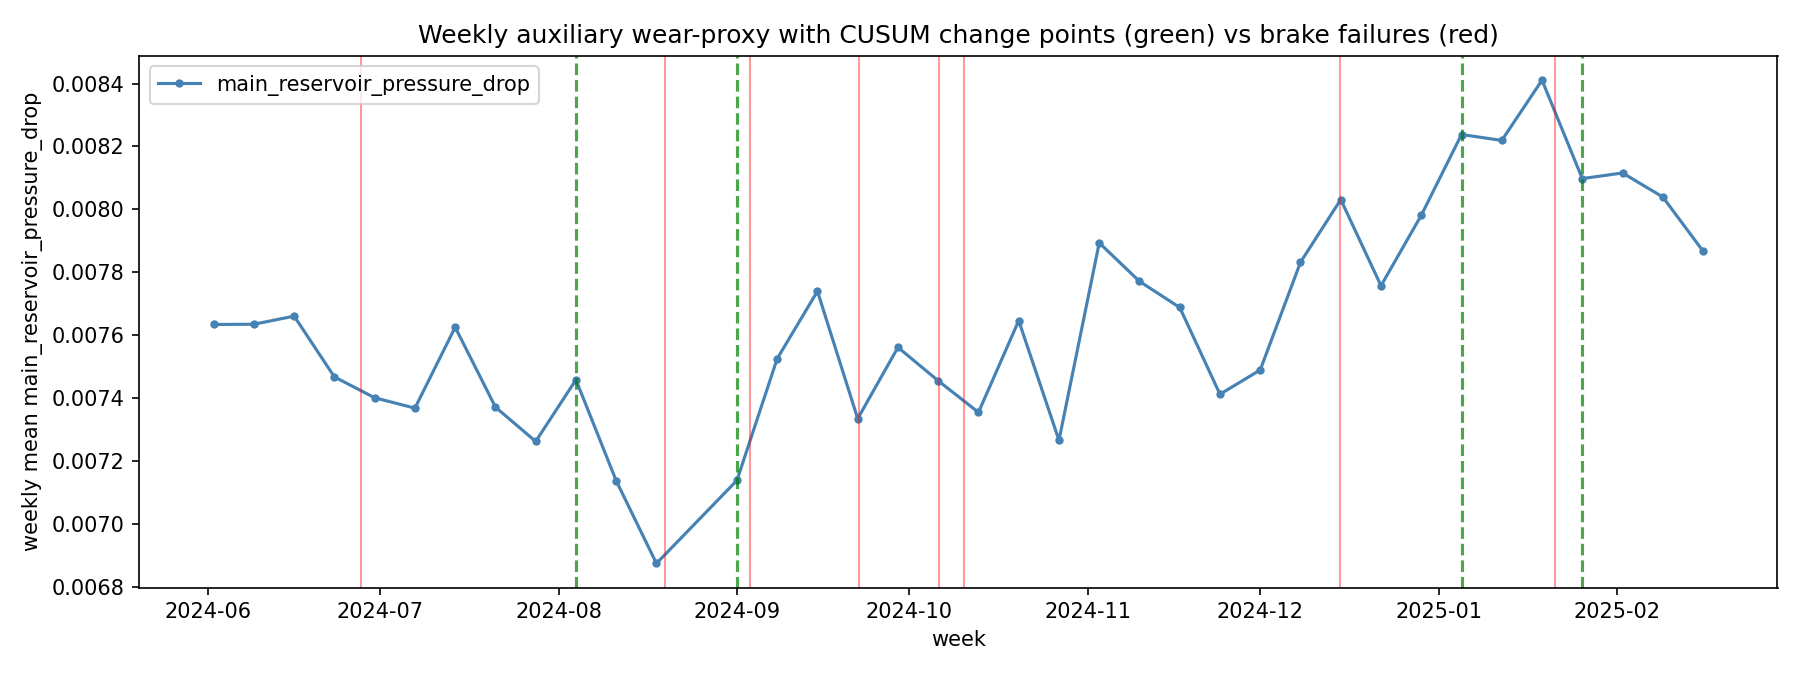

In [7]:
t = pd.read_csv(TABLES / "prefailure_tests.csv")
t["abs_delta"] = t["cliffs_delta"].abs()
display(t.sort_values("abs_delta", ascending=False)[
    ["feature", "cliffs_delta", "cliffs_ci_lo", "cliffs_ci_hi", "sig_bonferroni"]].round(3))
display(Image(filename=str(P2 / "prefailure_cusum.png")))

**What it means:** the pre-failure signal in *braking* is **weak**. With so
many events, almost everything is "statistically significant", but the actual effect sizes
are tiny — the only mild exceptions are two **auxiliary health sensors**
(energy-braking-resistance, load-pressure) which drift slightly before a failure.

**How confident:** low statistically (only 8 failures) — we report this as a genuine weak
/ near-null result, not a detector. It hints that failures may show up more during
*charging/idle* than during braking — a clear next step.

## Takeaways

1. Braking is **recoverable from the air sensors with no cheating** (AUC ≈ 0.9); the
   independent health sensors carry most of that signal.
2. Braking **intensity is a continuum**, not distinct classes.
3. Non-speed sensors explain **~43–47%** of how hard the train brakes (out-of-sample).
4. The **pre-failure braking signal is weak** (8 failures) — pointing toward an
   idle/charging follow-up.

## Techniques explained (plain language)

Each method we used, with an everyday analogy.

**Normalization / standardization** — Sensors come in different units and ranges. We
rescale each one so they're comparable (think: converting everyone's height and weight
to "how many standard deviations above/below average" so neither dominates just because
its numbers are bigger).

**Clustering** — Letting the data sort itself into natural groups, without telling it
the answer in advance (like sorting a pile of mixed coins into piles by size without
being told the denominations).

**k-means** — A clustering method: you pick how many groups *k* you want; it places *k*
"centres" and assigns each point to its nearest centre, then nudges the centres until
they settle. Fast and simple.

**Hierarchical clustering + dendrogram** — Builds a family tree of the data by repeatedly
merging the two closest groups. The tree (dendrogram) shows at what "distance" groups
merge, which hints at how many real groups there are. We run it on a sample because it's
memory-heavy on millions of rows.

**Choosing the number of groups (k):** we don't guess — we measure.
- **Silhouette** — how tightly packed and well-separated the groups are (higher = cleaner;
  ~1 is perfect, ~0 means overlapping).
- **Davies–Bouldin** — similar idea, lower = better.
- **BIC / AIC** — score a statistical model that rewards fitting the data but penalises
  needless complexity. A genuine "best k" shows up as a low point; if the score just keeps
  improving with more groups, there is no natural number of groups (a *continuum*).
- **Bootstrap + Adjusted Rand Index (ARI)** — re-draw the data many times, re-cluster, and
  check the groupings still agree (ARI ≈ 1 = stable, ≈ 0 = random). Stability is the
  decisive test: pretty groups that don't survive resampling aren't real.

**PCA (Principal Component Analysis)** — Squeezes many correlated sensors into a few
summary axes that capture most of the variation (like summarising a detailed survey by
its two or three main themes). Useful for plotting and for an *anomaly score*: if a
reading can't be rebuilt from those summary axes, it's unusual.

**Train / held-out split** — We fit models on one part of the data and score them on a
*different, unseen* part. Scoring on data the model already saw would be like grading an
exam with the answer key taped to it — meaningless.

**Decision tree / LDA / QDA** — Three transparent ways to draw the boundary between
classes: a decision tree asks a sequence of yes/no questions ("is pressure > x?"); LDA
draws a straight dividing line; QDA allows a curved one. We report all three so the result
doesn't depend on one method's quirks.

**Scoring a classifier:**
- **Accuracy** — fraction correct. Misleading when one class is rare.
- **Balanced accuracy** — accuracy averaged per class, so a rare class still counts.
- **Precision** — of the cases flagged positive, how many really were.
- **Recall** — of the real positives, how many we caught.
- **F1** — the balance of precision and recall (one number).
- **ROC-AUC** — probability the model ranks a real positive above a real negative; 0.5 =
  coin-flip, 1.0 = perfect.
- **Confusion matrix** — the table of right/wrong calls per class.

**Regression & R²** — Predicting a number (not a class). **R²** is the fraction of the
real variation the model explains: 0 = no better than always guessing the average, 1 =
perfect. **MAE** is the average size of the error. We always compare against a
**baseline** (guess-the-average) so the number means something.

**Comparing two groups of measurements:**
- **Mann–Whitney U / Kolmogorov–Smirnov** — tests for whether two groups differ.
- **p-value** — the chance of seeing a difference this big if there were truly none. With
  huge samples, *even trivial differences get tiny p-values*, so a small p alone is not
  "important".
- **Cliff's delta** — the *effect size*: how large the difference actually is (0 = none,
  ±1 = total separation). This is what we read, not the p-value alone.
- **Bonferroni correction** — when you run many tests, you tighten the bar to avoid being
  fooled by chance.

**CUSUM** — A cumulative drift alarm: it adds up small deviations from normal and raises a
flag once they pile up, good at catching slow trends. **Lead time** = how far ahead of a
failure it fired; **false-alarm rate** = how often it cries wolf.

**SHAP** *(used in Phase 3)* — Explains a prediction by how much each sensor pushed it up
or down, like an itemised receipt for the model's decision.

**Leakage / circularity (the key idea behind this whole study)** — A predictor must never
have helped define the thing it's predicting. If you label "hard braking" using
deceleration and then "predict" that label using deceleration, you've just memorised your
own definition — you'll score ~100 % and learn nothing. We avoid this by defining
operational states from **motion only** and predicting them from the **air-system sensors
only**, which never touched the definition.